# Air Quality Prediction — Model Training

Trains models on **hourly historical data for Kigali and Delhi** (free Open-Meteo archive)
at **two forecast horizons**, to contrast a trivial baseline with a real forecast:

- **+1 hour** — a *persistence* baseline (next-hour AQI ~= current AQI, very high R^2 but trivial)
- **+24 hours** — a genuine *next-day* forecast where weather, hour and season actually matter

For each horizon we train:

- **Regression** — the AQI value (`RandomForestRegressor`)
- **Classification** — the AQI category (`RandomForestClassifier`)

Feature set (matches the live IQAir data fed in by the Django `predictor` app):
`aqi_us, temperature_c, humidity, pressure_hpa, wind_speed_ms, hour, month`.

**Why Random Forest?** Handles non-linear weather/pollution interactions, needs no
scaling, is robust to outliers, and exposes feature importances. Trees are depth-limited
so the exported `.joblib` files stay small enough to submit.

Exports four artifacts to `ml/artifacts/`:
`aqi_regressor_1h`, `aqi_classifier_1h`, `aqi_regressor_24h`, `aqi_classifier_24h`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import requests
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix,
)

# Resolve project paths whether the notebook runs from the project root or ml/
BASE = Path.cwd()
if BASE.name == "ml":
    BASE = BASE.parent
DATA_DIR = BASE / "ml" / "data"
ART_DIR = BASE / "ml" / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
print("Project base:", BASE)

Project base: C:\Users\buble\OneDrive\Desktop\vault\BIGDATA\COHORT_2023\web_development\FINAL_PROJECT\Real-Time Environmental Health Monitoring and Air Quality Prediction Dashboard Using Machine Learning


## 1. Download historical data (Open-Meteo)

12 months of hourly air quality (`us_aqi`, `pm2_5`) + weather
(`temperature, humidity, surface pressure, wind speed`) for each city.
Wind is requested in m/s so it matches IQAir's live units.

In [2]:
CITIES = {
    "Kigali": (-1.9499, 30.0588),
    "Delhi": (28.6667, 77.1167),
}
START, END = "2025-07-01", "2026-06-30"   # ~12 months of hourly data

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
WX_URL = "https://archive-api.open-meteo.com/v1/archive"


def fetch_city(name, lat, lon):
    aq = requests.get(AQ_URL, params={
        "latitude": lat, "longitude": lon,
        "hourly": "us_aqi,pm2_5",
        "start_date": START, "end_date": END, "timezone": "UTC",
    }, timeout=120).json()
    wx = requests.get(WX_URL, params={
        "latitude": lat, "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
        "start_date": START, "end_date": END, "timezone": "UTC",
        "wind_speed_unit": "ms",
    }, timeout=120).json()

    aq_df = pd.DataFrame(aq["hourly"]).rename(columns={"us_aqi": "aqi_us"})
    wx_df = pd.DataFrame(wx["hourly"]).rename(columns={
        "temperature_2m": "temperature_c",
        "relative_humidity_2m": "humidity",
        "surface_pressure": "pressure_hpa",
        "wind_speed_10m": "wind_speed_ms",
    })
    df = pd.merge(aq_df, wx_df, on="time")
    df["city"] = name
    return df


frames = [fetch_city(name, lat, lon) for name, (lat, lon) in CITIES.items()]
data = pd.concat(frames, ignore_index=True)
data["time"] = pd.to_datetime(data["time"])
data.to_csv(DATA_DIR / "historical_air_quality.csv", index=False)
print("Downloaded rows:", len(data))
data.head()

Downloaded rows: 17520


,time,aqi_us,pm2_5,temperature_c,humidity,pressure_hpa,wind_speed_ms,city
0,2025-07-01 00:00:00,67,13.2,17.0,73,851.3,1.04,Kigali
1,2025-07-01 01:00:00,66,14.6,15.9,74,850.4,1.59,Kigali
2,2025-07-01 02:00:00,65,16.9,16.0,75,850.5,1.56,Kigali
3,2025-07-01 03:00:00,65,18.6,15.8,76,850.7,1.48,Kigali
4,2025-07-01 04:00:00,64,21.0,14.7,81,850.5,1.59,Kigali


## 2. Feature engineering

We add a **`city_id`** feature (city-specific behaviour) and **lag/trend features**
(`aqi_lag_1/3/6/24`, a 6-hour rolling mean, and a 3-hour slope) so the model can see
the recent **trajectory** — whether AQI is rising or falling — instead of only the
current value. This is the fix for the model over-predicting a city that is mid-decline.
Two forecast targets are created by shifting AQI within each city:
`target_aqi_1h` (shift -1) and `target_aqi_24h` (shift -24).
Categories follow the US EPA AQI bands.

In [3]:
data = data.sort_values(["city", "time"]).reset_index(drop=True)
data["hour"] = data["time"].dt.hour
data["month"] = data["time"].dt.month

# City as a feature so the model can learn city-specific behaviour.
# NOTE: this mapping MUST match predictor/services.py CITY_ID.
CITY_ID = {"Kigali": 0, "Delhi": 1}
data["city_id"] = data["city"].map(CITY_ID)

# Lag / trend features (per city) so the model sees the recent trajectory,
# not just the current value — this is what lets it capture rising/falling AQI.
for lag in [1, 3, 6, 24]:
    data[f"aqi_lag_{lag}"] = data.groupby("city")["aqi_us"].shift(lag)
data["aqi_roll6"] = data.groupby("city")["aqi_us"].transform(lambda x: x.shift(1).rolling(6).mean())
data["aqi_trend3"] = data["aqi_us"] - data["aqi_lag_3"]

# Two forecast horizons
data["target_aqi_1h"] = data.groupby("city")["aqi_us"].shift(-1)
data["target_aqi_24h"] = data.groupby("city")["aqi_us"].shift(-24)

FEATURES = ["aqi_us", "temperature_c", "humidity", "pressure_hpa", "wind_speed_ms", "hour", "month", "city_id",
            "aqi_lag_1", "aqi_lag_3", "aqi_lag_6", "aqi_lag_24", "aqi_roll6", "aqi_trend3"]


def aqi_category(aqi):
    bands = [(50, "Good"), (100, "Moderate"), (150, "Unhealthy for Sensitive Groups"),
             (200, "Unhealthy"), (300, "Very Unhealthy"), (10**9, "Hazardous")]
    for upper, label in bands:
        if aqi <= upper:
            return label
    return "Hazardous"


print("Total rows:", len(data))
print(data[["aqi_us", "temperature_c", "humidity", "pressure_hpa", "wind_speed_ms"]].describe().round(1))

Total rows: 17520
        aqi_us  temperature_c  humidity  pressure_hpa  wind_speed_ms
count  17520.0        17520.0   17520.0       17520.0        17520.0
mean     143.5           22.8      65.4         917.1            1.8
std      111.5            6.7      22.7          66.8            0.9
min       35.0            4.1       9.0         844.0            0.0
25%       72.0           17.4      48.0         850.4            1.1
50%      112.0           22.3      68.0         912.7            1.7
75%      168.0           27.3      85.0         983.5            2.4
max      915.0           44.3     100.0         999.4            7.5


## 3. Train both horizons (regression + classification)

Tree depth and leaf size are capped to keep the exported models small.

In [4]:
HORIZONS = [1, 24]
RF_REG = dict(n_estimators=100, max_depth=14, min_samples_leaf=8, random_state=42, n_jobs=-1)
RF_CLS = dict(n_estimators=120, max_depth=16, min_samples_leaf=4, random_state=42, n_jobs=-1)

models = {}
results = {}

for h in HORIZONS:
    tgt = f"target_aqi_{h}h"
    sub = data.dropna(subset=FEATURES + [tgt]).reset_index(drop=True)
    X = sub[FEATURES].to_numpy()
    y_reg = sub[tgt].to_numpy()
    y_cls = sub[tgt].apply(aqi_category).to_numpy()

    # Regression
    Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2, random_state=42)
    reg = RandomForestRegressor(**RF_REG).fit(Xtr, ytr)
    pr = reg.predict(Xte)
    rmse = root_mean_squared_error(yte, pr)
    mae = mean_absolute_error(yte, pr)
    r2 = r2_score(yte, pr)

    # Classification
    Xtr, Xte, ytr, yte = train_test_split(X, y_cls, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(**RF_CLS).fit(Xtr, ytr)
    pc = clf.predict(Xte)
    acc = accuracy_score(yte, pc)
    f1 = f1_score(yte, pc, average="weighted")

    models[h] = (reg, clf)
    results[h] = {"rows": len(sub), "rmse": rmse, "mae": mae, "r2": r2,
                  "acc": acc, "f1": f1,
                  "y_true": yte, "y_pred": pc, "labels": sorted(set(y_cls))}

    imp = pd.Series(reg.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print(f"[+{h:>2}h] rows={len(sub):>6}  REG: RMSE={rmse:5.2f} MAE={mae:5.2f} R2={r2:.3f}"
          f"   CLS: acc={acc:.3f} f1={f1:.3f}")
    print("        top features: " + ", ".join(f"{f}={v:.3f}" for f, v in imp.head(3).items()))

[+ 1h] rows= 17470  REG: RMSE= 4.36 MAE= 1.67 R2=0.999   CLS: acc=0.976 f1=0.976
        top features: aqi_us=0.999, aqi_trend3=0.001, aqi_lag_1=0.000


[+24h] rows= 17424  REG: RMSE=40.61 MAE=19.11 R2=0.874   CLS: acc=0.883 f1=0.879
        top features: aqi_us=0.687, pressure_hpa=0.056, humidity=0.040


### Reading the contrast

- **+1h** leans almost entirely on `aqi_us` (persistence) — high R^2 but it is mostly
  echoing the current value.
- **+24h** spreads importance onto weather / `hour` / `month`, so the model is genuinely
  forecasting. Its R^2 is lower but far more meaningful — this is the model to defend in the viva.

## 4. Per-class report + confusion matrix (+24h classifier)

                                precision    recall  f1-score   support

                          Good       0.76      0.36      0.49        36
                     Hazardous       0.79      0.87      0.83       249
                      Moderate       0.94      0.96      0.95      1528
                     Unhealthy       0.84      0.93      0.88       926
Unhealthy for Sensitive Groups       0.82      0.73      0.77       528
                Very Unhealthy       0.90      0.60      0.72       218

                      accuracy                           0.88      3485
                     macro avg       0.84      0.74      0.77      3485
                  weighted avg       0.88      0.88      0.88      3485



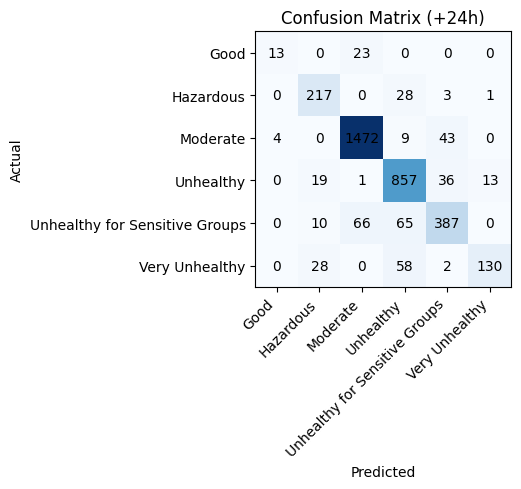

In [5]:
h = 24
print(classification_report(results[h]["y_true"], results[h]["y_pred"]))

labels = results[h]["labels"]
cm = confusion_matrix(results[h]["y_true"], results[h]["y_pred"], labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (+{h}h)")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

## 5. Export models (joblib)

Four artifacts saved into `ml/artifacts/`, then loaded by the Django `predictor` app.

In [6]:
for h, (reg, clf) in models.items():
    joblib.dump(reg, ART_DIR / f"aqi_regressor_{h}h.joblib")
    joblib.dump(clf, ART_DIR / f"aqi_classifier_{h}h.joblib")

print("Saved artifacts:")
for p in sorted(ART_DIR.glob("*.joblib")):
    print(f" - {p.name:<28} {p.stat().st_size/1e6:6.2f} MB")

Saved artifacts:
 - aqi_classifier_1h.joblib       4.81 MB
 - aqi_classifier_24h.joblib     19.97 MB
 - aqi_regressor_1h.joblib       11.59 MB
 - aqi_regressor_24h.joblib       9.56 MB
